In [2]:
import os
import sys
import numpy as np
import pandas as pd
import nibabel as nib
import nilearn
from nilearn.image import resample_img
from nilearn import plotting
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from nilearn import masking
from natsort import natsorted
import pickle

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import matplotlib.pyplot as plt
from scipy.stats import zscore

from sklearn.model_selection import RepeatedStratifiedKFold

from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Load MNI mask for ROIs betas

In [2]:
maskDir = 'F:\yujun\projects\data\masks'
maskFile = os.path.join(maskDir, 'MNI152_T1_2mm_brain_mask.nii.gz')
mask = nib.load(maskFile)

In [3]:
mask.get_fdata().shape

(91, 109, 91)

# Resample MNI mask

In [44]:
temp_nii_path = r'F:\yujun\projects\AI_IAPS\GLM_singletrial\\betas\Sub1\\beta_0001.nii'
temp_nii_data = nib.load(temp_nii_path)
# Resample the MNI mask to match the dimensions and voxel size of your NIfTI file
resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
resampled_mask.shape

(79, 95, 79)

# Load Kastner mask

In [43]:
mask_temp= nib.load(f'F:\yujun\projects\data\masks\Kastner\IPS.img')

### Thresholding method (Abandoned)

In [274]:
# roi_id = np.arange(1, 26)

# roi_labels = ['V1v',	    
#  'V1d',	   
#  'V2v',   
#  'V2d',	   
#  'V3v',	    
#  'V3d',	    
#  'hV4',	  
#  'VO1',	    
#  'VO2',	    
#  'PHC1',	    
#  'PHC2',	    
#  'MST',	    
#  'hMT',	   
#  'LO2',	    
#  'LO1',	   
#  'V3b',	    
#  'V3a',	  
#  'IPS0',	   
#  'IPS1',	    
#  'IPS2',	    
#  'IPS3',	  
#  'IPS4',	  
#  'IPS5',	  
#  'SPL1',	 
#  'FEF'	]

# roi_bin = []
# roi_masks = []

# for i in range(len(roi_id)):
#     kastner_dir = 'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all'
#     kastner_l = nib.load(f'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all\\perc_VTPM_vol_roi{i+1}_lh.nii.gz')
#     kastner_r = nib.load(f'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all\\perc_VTPM_vol_roi{i+1}_rh.nii.gz')
#     kastner_combine = kastner_l.get_fdata() + kastner_r.get_fdata()
#     kastner_combine_nii = nib.Nifti1Image(kastner_combine, kastner_l.affine)
#     # Resample Kastner mask
#     kastner_resample = resample_img(kastner_combine_nii, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
#     # Create a binary mask where values > 0 are set to 1 and other values are set to 0
#     kastner_resample_bin = np.where(kastner_resample.get_fdata() > 10, 1, 0)
#     roi_bin.append(kastner_resample_bin)
#     roi_masks.append(nib.Nifti1Image(kastner_resample_bin, temp_nii_data.affine))

# for roi in roi_bin:
# # print(f'The ROI mask dimension is: {kastner_resample_bin.shape}')
# # total_voxels_count = kastner_resample_bin.shape[0] * kastner_resample_bin.shape[1] * kastner_resample_bin.shape[2]
# # print(f'The total number of voxels is: {total_voxels_count}')
#     print(f'There are {np.count_nonzero(roi)} voxels in the ROI mask')

# roi_masks = dict(zip(roi_labels, roi_masks))

There are 2497 voxels in the ROI mask
There are 2389 voxels in the ROI mask
There are 2295 voxels in the ROI mask
There are 2174 voxels in the ROI mask
There are 1762 voxels in the ROI mask
There are 2130 voxels in the ROI mask
There are 1561 voxels in the ROI mask
There are 873 voxels in the ROI mask
There are 916 voxels in the ROI mask
There are 826 voxels in the ROI mask
There are 957 voxels in the ROI mask
There are 772 voxels in the ROI mask
There are 1249 voxels in the ROI mask
There are 1085 voxels in the ROI mask
There are 1368 voxels in the ROI mask
There are 1196 voxels in the ROI mask
There are 1911 voxels in the ROI mask
There are 1978 voxels in the ROI mask
There are 1649 voxels in the ROI mask
There are 1585 voxels in the ROI mask
There are 1244 voxels in the ROI mask
There are 1307 voxels in the ROI mask
There are 1166 voxels in the ROI mask
There are 1434 voxels in the ROI mask
There are 2688 voxels in the ROI mask


### Labeling method

In [10]:
# kastner_maxprob_l = nib.load(f'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all\\maxprob_vol_lh.nii.gz')
# kastner_maxprob_r = nib.load(f'F:\yujun\projects\data\masks\ProbAtlas_v4\ProbAtlas_v4\subj_vol_all\\maxprob_vol_rh.nii.gz')   
# kastner_maxprob_combine = kastner_maxprob_l.get_fdata() + kastner_maxprob_r.get_fdata()
# kastner_kastner_maxprob_combine_nii = nib.Nifti1Image(kastner_maxprob_combine, kastner_maxprob_r.affine)
# kastner_maxprob_resample = resample_img(kastner_kastner_maxprob_combine_nii, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
# # Round the values to the nearest integer to preserve ROI labels
# kastner_maxprob_data = np.round(kastner_maxprob_resample.get_fdata())
# kastner_maxprob_resample_nii = nib.Nifti1Image(kastner_maxprob_data, kastner_maxprob_r.affine)
# np.save( 'F:\yujun\projects\data\masks\kastner_maxprob_data.npy',kastner_maxprob_data)
# nib.save(kastner_maxprob_resample_nii, 'F:\yujun\projects\data\masks\kastner79.nii')

# print("Original: " , kastner_maxprob_combine.shape, '\n', "Resampled: ", kastner_maxprob_resample.get_fdata().shape)

Original:  (182, 218, 182) 
 Resampled:  (79, 95, 79)


In [45]:
# The specific ROI labels to keep, in the desired order
roi_labels = [
    'V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 
    'V3a', 'V3b', 'LO1', 'LO2', 'VO1', 'VO2', 'IPS', 'PHC1', 'PHC2'
]

# The label indices corresponding to these ROIs
# IPS is a combination of multiple labels, hence grouping 18-23
label_ids_to_keep = {
    'V1v': 1, 'V1d': 2, 'V2v': 3, 'V2d': 4, 'V3v': 5, 'V3d': 6, 'hV4': 7, 
    'V3a': 17, 'V3b': 16, 'LO1': 15, 'LO2': 14, 'VO1': 8, 'VO2': 9, 
    'IPS': [18, 19, 20, 21, 22, 23], 'PHC1': 10, 'PHC2': 11
}

# Load the kastner template data
kastner_maxprob_data = np.load('F:\\yujun\\projects\\data\\masks\\kastner_maxprob_data.npy')

# Separate each ROI into its own mask and save to a dictionary
roi_masks = {}

for roi_name, label_id in label_ids_to_keep.items():
    if isinstance(label_id, list):  # For IPS, which is a combination of multiple labels
        roi_mask_data = np.isin(kastner_maxprob_data, label_id).astype(int)
    else:
        roi_mask_data = (kastner_maxprob_data == label_id).astype(int)
    
    # Create a Nifti image for the mask
    roi_mask_img = nib.Nifti1Image(roi_mask_data, affine=temp_nii_data.affine)
    
    # Example of saving the mask; adjust filenames as needed
    # nib.save(roi_mask_img, f'{roi_name}.nii.gz')
    
    # Store in dictionary
    roi_masks[roi_name] = roi_mask_img

# Now roi_masks dictionary contains only the ROIs you're interested in, with IPS regions combined.

In [15]:
kastner_maxprob_data.shape

(79, 95, 79)

In [8]:
for (k, v) in roi_masks.items():
    print(k, v.get_fdata().shape, np.count_nonzero(v.get_fdata()))

V1v (79, 95, 79) 856
V1d (79, 95, 79) 748
V2v (79, 95, 79) 727
V2d (79, 95, 79) 645
V3v (79, 95, 79) 527
V3d (79, 95, 79) 517
hV4 (79, 95, 79) 328
V3a (79, 95, 79) 554
V3b (79, 95, 79) 263
LO1 (79, 95, 79) 324
LO2 (79, 95, 79) 125
VO1 (79, 95, 79) 153
VO2 (79, 95, 79) 253
IPS (79, 95, 79) 973
PHC1 (79, 95, 79) 175
PHC2 (79, 95, 79) 165


c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\image\resampling.py:756: UserWarning: Casting data from int32 to float32
  return resample_img(
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\image\resampling.py:293: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn(



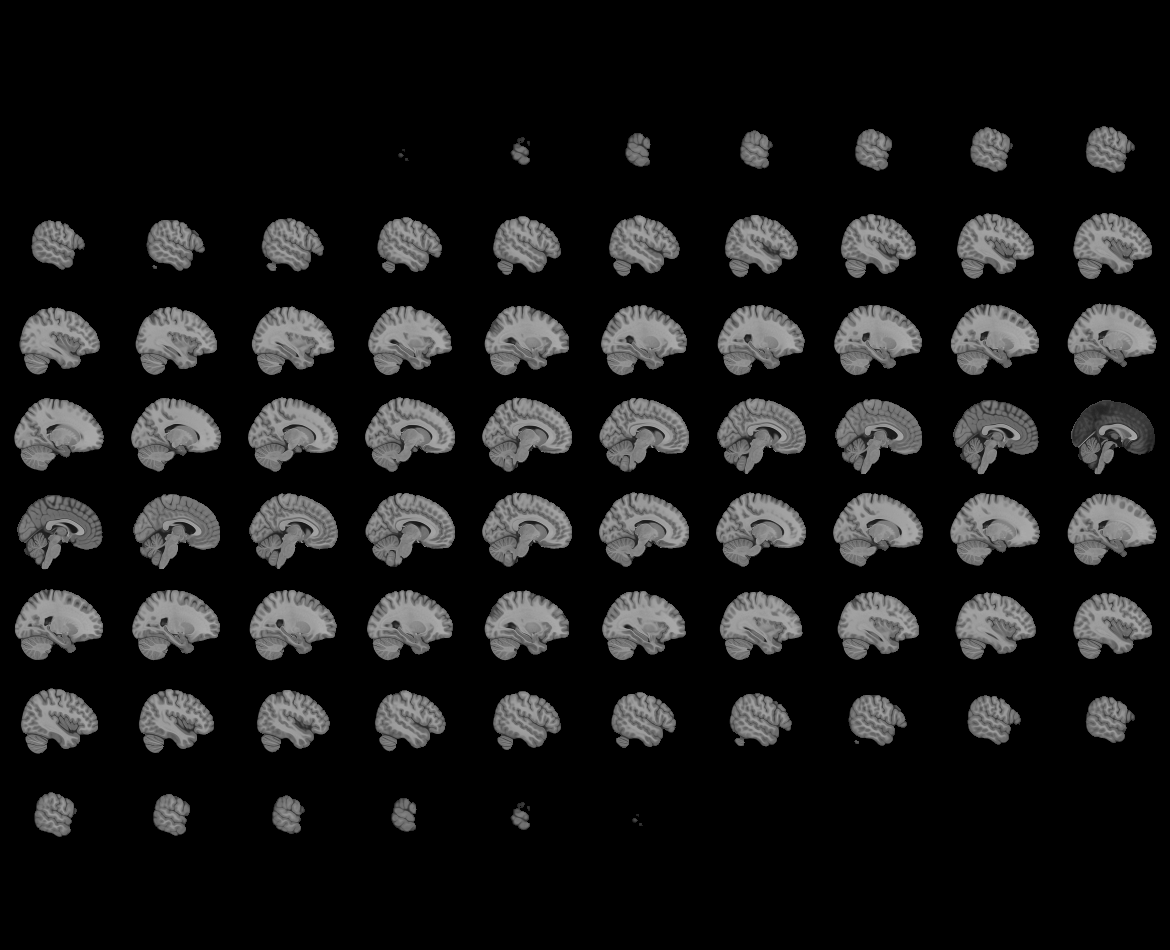
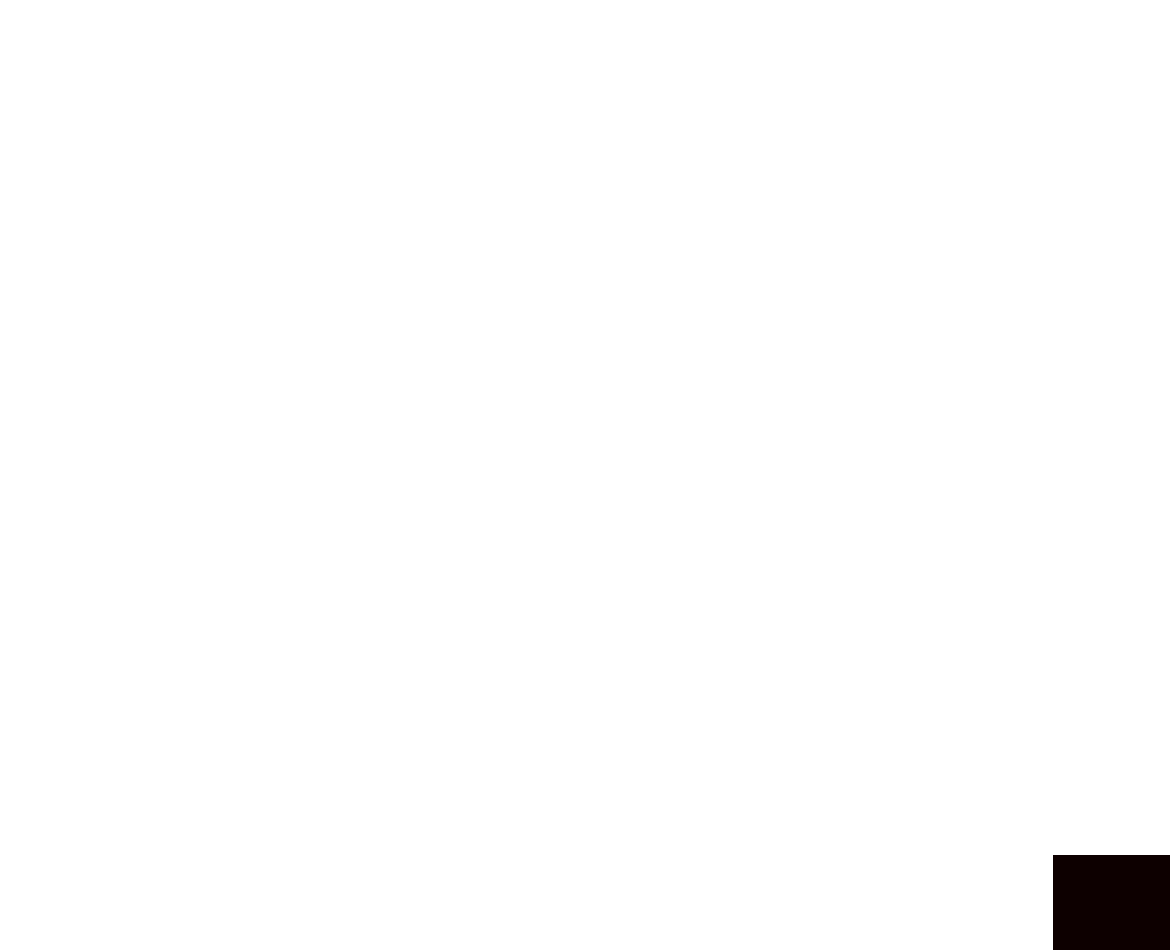

In [16]:
roi = 'IPS'
view = plotting.view_img(roi_masks[roi], title = roi)
view

In [47]:
# Save the dictionary to a file
with open('kastner_dict.pkl', 'wb') as f:
    pickle.dump(roi_masks, f)

In [48]:
# Load the dictionary from the file
with open('kastner_dict.pkl', 'rb') as f:
    roi_masks = pickle.load(f)


# Load AAL3 mask

In [113]:
aal_rois_files = ['ACCpre',
 'ACCsub',
 'ACCsup',
 'Amygdala',
 'Angular',
 'Calcarine',
 'Caudate',
 'Cerebellum',
 'Cuneus',
 'FrontalInfOper',
 'FrontalInfOrb',
 'FrontalInfTri',
 'FrontalMedOrb',
 'FrontalMid',
 'FrontalSup',
 'FrontalSupMedial',
 'Fusiform',
 'Heschl',
 'Hippocampus',
 'Insula',
 'LC',
 'Lingual',
 'NAcc',
 'OccipitalInf',
 'OccipitalMid',
 'OccipitalSup',
 'OFCant',
 'OFClat',
 'OFCmed',
 'OFCpost',
 'Pallidum',
 'ParacentralLobule',
 'ParaHippocampal',
 'ParietalInf',
 'ParietalSup',
 'Postcentral',
 'Precentral',
 'Precuneus',
 'Putamen',
 'RedN',
 'RolandicOper',
 'SNpc',
 'SNpr',
 'SuppMotorArea',
 'SupraMarginal',
 'TemporalInf',
 'TemporalMid',
 'TemporalPoleMid',
 'TemporalPoleSup',
 'TemporalSup',
 'ThalAV',
 'ThalIL',
 'ThalLGN',
 'ThalLP',
 'ThalMDl',
 'ThalMDm',
 'ThalMGN',
 'ThalPuA',
 'ThalPuI',
 'ThalPuL',
 'ThalPuM',
 'ThalRe',
 'ThalVA',
 'ThalVL',
 'ThalVPL']

In [114]:
# aal_rois_files = os.listdir("F:\yujun\projects\data\masks\AAL3\\new")
aal_rois = [string.split('.')[0] for string in aal_rois_files]
aal_rois

['ACCpre',
 'ACCsub',
 'ACCsup',
 'Amygdala',
 'Angular',
 'Calcarine',
 'Caudate',
 'Cerebellum',
 'Cuneus',
 'FrontalInfOper',
 'FrontalInfOrb',
 'FrontalInfTri',
 'FrontalMedOrb',
 'FrontalMid',
 'FrontalSup',
 'FrontalSupMedial',
 'Fusiform',
 'Heschl',
 'Hippocampus',
 'Insula',
 'LC',
 'Lingual',
 'NAcc',
 'OccipitalInf',
 'OccipitalMid',
 'OccipitalSup',
 'OFCant',
 'OFClat',
 'OFCmed',
 'OFCpost',
 'Pallidum',
 'ParacentralLobule',
 'ParaHippocampal',
 'ParietalInf',
 'ParietalSup',
 'Postcentral',
 'Precentral',
 'Precuneus',
 'Putamen',
 'RedN',
 'RolandicOper',
 'SNpc',
 'SNpr',
 'SuppMotorArea',
 'SupraMarginal',
 'TemporalInf',
 'TemporalMid',
 'TemporalPoleMid',
 'TemporalPoleSup',
 'TemporalSup',
 'ThalAV',
 'ThalIL',
 'ThalLGN',
 'ThalLP',
 'ThalMDl',
 'ThalMDm',
 'ThalMGN',
 'ThalPuA',
 'ThalPuI',
 'ThalPuL',
 'ThalPuM',
 'ThalRe',
 'ThalVA',
 'ThalVL',
 'ThalVPL']

In [118]:
aal3_bins = []
aal3_masks = []

for i in range(len(aal_rois)):
    aal3_nii = nib.load(f'F:\yujun\projects\data\masks\AAL3\\new\{aal_rois[i]}.nii.gz')
    aal3_resample = resample_img(aal3_nii, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
    aal3_bin = np.where(aal3_resample.get_fdata() > 0, 1, 0)
    aal3_masks.append(nib.Nifti1Image(aal3_bin, temp_nii_data.affine))
    
aal3_dict = dict(zip(aal_rois, aal3_masks))

In [119]:
len(aal3_dict)

65

In [120]:
np.save("./aal3_dict_65rois.npy", aal3_dict)

## Combine ROIs

In [227]:
# rois_dict = kastner_dict
# rois_dict.update(aal3_dict)
# len(rois_dict)

43

In [246]:
# np.save("./rois_dict.npy", rois_dict)

# Load beta series and apply MNI mask

Define beta ids, clean out movement and baseline betas

In [3]:
beta_idx = []
for i in range(0 ,10): # runs
    id = [(x + 66*i) for x in range(1,61)]
    beta_idx.append(id)
beta_id = np.array(beta_idx).reshape(1, -1)
beta_id

array([[  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
         40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
         53,  54,  55,  56,  57,  58,  59,  60,  67,  68,  69,  70,  71,
         72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,
         85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
         98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
        111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123,
        124, 125, 126, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181,
        182, 183, 184, 185, 186, 187, 188, 189, 190

In [6]:
beta_id.shape

(1, 600)

In [67]:
dataDir = '../GLM_singletrial/betas/'
subs = ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub11', 'Sub12']

# Loop through each subject and assert their existence
for sub in subs:
    sub_path = os.path.join(dataDir, sub)
    if not os.path.isdir(sub_path):
        raise FileNotFoundError(f"Folder for {sub} does not exist at path: {sub_path}")
    else:
        print(f"Folder for {sub} exists at path: {sub_path}")


Folder for Sub1 exists at path: ../GLM_singletrial/betas/Sub1
Folder for Sub2 exists at path: ../GLM_singletrial/betas/Sub2
Folder for Sub3 exists at path: ../GLM_singletrial/betas/Sub3
Folder for Sub4 exists at path: ../GLM_singletrial/betas/Sub4
Folder for Sub5 exists at path: ../GLM_singletrial/betas/Sub5
Folder for Sub6 exists at path: ../GLM_singletrial/betas/Sub6
Folder for Sub7 exists at path: ../GLM_singletrial/betas/Sub7
Folder for Sub8 exists at path: ../GLM_singletrial/betas/Sub8
Folder for Sub9 exists at path: ../GLM_singletrial/betas/Sub9
Folder for Sub11 exists at path: ../GLM_singletrial/betas/Sub11
Folder for Sub12 exists at path: ../GLM_singletrial/betas/Sub12


In [8]:
beta_series = []
z_series = []

for sub in subs:
    sub_dir = os.path.join(dataDir, sub)
    filenames = os.listdir(sub_dir)
    # Extract the IDs from the filenames
    file_ids = [int(os.path.splitext(filename)[0].split('_')[1]) for filename in filenames if os.path.splitext(filename)[0].split('_')[0] == 'beta']
    # Filter the filenames based on the ID list
    selected_filenames = [filename for filename, file_id in zip(filenames, file_ids) if file_id in beta_id]
    # print(f'Number of betas for the subject: {len(selected_filenames)}')
    
    sub_beta_series = []
    sub_z_series = []
    for i in tqdm(range(len(selected_filenames))):
        # Load the NIfTI file
        file_path = os.path.join(dataDir, sub, selected_filenames[i])
        nii_data = nib.load(file_path)
        # Apply the mask to the NIfTI image
        masked_data = masking.apply_mask(nii_data, resampled_mask)
        # Get the mask's indices in the original 3D shape
        mask_indices = np.where(resampled_mask.get_fdata())
        # Create a new 3D array filled with zeros
        reshaped_data = np.empty(nii_data.shape)
        reshaped_data[:] = np.nan
        # Fill the new 3D array with the values from the masked data
        reshaped_data[mask_indices] = masked_data
        sub_beta_series.append(reshaped_data)

    sub_beta_arrays = np.array(sub_beta_series)
    beta_series.append(sub_beta_arrays)
    # z-score standardization
    # Calculate the mean and standard deviation along axis 0
    mean = sub_beta_arrays.mean(axis=0)
    std = sub_beta_arrays.std(axis=0)
    # Avoid division by zero for voxels with zero variance
    std[std == 0] = 1
    # Perform z-score standardization along axis 0
    sub_z_series = (sub_beta_arrays - mean) / std
    z_series.append(sub_z_series)


Processing subjects and trials:  88%|████████▊ | 6600/7473 [38:52<05:08,  2.83it/s]  


In [ ]:
beta_series = []
z_series = []

# Get total number of iterations across subjects and trials
total_trials = sum([len(os.listdir(os.path.join(dataDir, sub))) for sub in subs])

# Create a tqdm progress bar over all subjects and trials
with tqdm(total=total_trials, desc="Processing subjects and trials") as pbar:
    for sub in subs:
        sub_dir = os.path.join(dataDir, sub)
        filenames = os.listdir(sub_dir)
        # Extract the IDs from the filenames
        file_ids = [int(os.path.splitext(filename)[0].split('_')[1]) for filename in filenames if os.path.splitext(filename)[0].split('_')[0] == 'beta']
        # Filter the filenames based on the ID list
        selected_filenames = [filename for filename, file_id in zip(filenames, file_ids) if file_id in beta_id]
        
        sub_beta_series = []
        sub_z_series = []
        
        for i in range(len(selected_filenames)):
            # Load the NIfTI file
            file_path = os.path.join(dataDir, sub, selected_filenames[i])
            nii_data = nib.load(file_path)
            # Apply the mask to the NIfTI image
            masked_data = masking.apply_mask(nii_data, resampled_mask)
            # Get the mask's indices in the original 3D shape
            mask_indices = np.where(resampled_mask.get_fdata())
            # Create a new 3D array filled with NaN
            reshaped_data = np.empty(nii_data.shape)
            reshaped_data[:] = np.nan
            # Fill the new 3D array with the values from the masked data
            reshaped_data[mask_indices] = masked_data
            sub_beta_series.append(reshaped_data)
            
            # Update progress bar after each trial
            pbar.update(1)
        
        sub_beta_arrays = np.array(sub_beta_series)
        beta_series.append(sub_beta_arrays)
        
        # z-score standardization
        mean = sub_beta_arrays.mean(axis=0)
        std = sub_beta_arrays.std(axis=0)
        
        # Avoid division by zero for voxels with zero variance
        std[std == 0] = np.nan
        
        # Perform z-score standardization along axis 0
        sub_z_series = (sub_beta_arrays - mean) / std
        z_series.append(sub_z_series)

In [87]:
beta_series = []
z_series = []

# Get total number of iterations across subjects and trials
total_trials = sum([len(os.listdir(os.path.join(dataDir, sub))) for sub in subs])

# Create a tqdm progress bar over all subjects and trials
with tqdm(total=total_trials, desc="Processing subjects and trials") as pbar:
    for sub in subs:
        sub_dir = os.path.join(dataDir, sub)
        filenames = os.listdir(sub_dir)
        # Extract the IDs from the filenames
        file_ids = [int(os.path.splitext(filename)[0].split('_')[1]) for filename in filenames if os.path.splitext(filename)[0].split('_')[0] == 'beta']
        # Filter the filenames based on the ID list
        selected_filenames = [filename for filename, file_id in zip(filenames, file_ids) if file_id in beta_id]
        
        sub_beta_series = []
        sub_z_series = []
        
        for i in range(len(selected_filenames)):
            # Load the NIfTI file
            file_path = os.path.join(dataDir, sub, selected_filenames[i])
            nii_data = nib.load(file_path)
            # Apply the mask to the NIfTI image
            masked_data = masking.apply_mask(nii_data, resampled_mask)
            # Get the mask's indices in the original 3D shape
            mask_indices = np.where(resampled_mask.get_fdata())
            # Create a new 3D array filled with NaN
            reshaped_data = np.empty(nii_data.shape)
            reshaped_data[:] = np.nan
            # Fill the new 3D array with the values from the masked data
            reshaped_data[mask_indices] = masked_data
            sub_beta_series.append(reshaped_data)
            
            # Update progress bar after each trial
            pbar.update(1)
        
        sub_beta_arrays = np.array(sub_beta_series)
        beta_series.append(sub_beta_arrays)
        
        # z-score standardization
        mean = sub_beta_arrays.mean(axis=0)
        std = sub_beta_arrays.std(axis=0)
        
        # Avoid division by zero for voxels with zero variance
        std[std == 0] = 1
        
        # Perform z-score standardization along axis 0
        sub_z_series = (sub_beta_arrays - mean) / std
        z_series.append(sub_z_series)

Processing subjects and trials:  88%|████████▊ | 6600/7473 [47:24<06:16,  2.32it/s]  


In [10]:
beta_series_arr = np.array(beta_series)
beta_series_arr.shape

(11, 600, 79, 95, 79)

In [11]:
z_series_arr = np.array(z_series, dtype=np.float32)
z_series_arr.shape

(11, 600, 79, 95, 79)

In [12]:
p1 = np.count_nonzero(np.isnan(beta_series_arr))/(np.count_nonzero(np.isnan(beta_series_arr))+np.count_nonzero(~np.isnan(beta_series_arr)))
print(f"nan ratio in beta series: {p1}")

nan ratio in beta series: 0.6147395407281222


In [13]:
p2 = np.count_nonzero(np.isnan(z_series_arr))/(np.count_nonzero(np.isnan(z_series_arr))+np.count_nonzero(~np.isnan(z_series_arr)))
print(f"nan ratio in z series: {p2}")

nan ratio in z series: 0.6475681344772837


Save beta and Z series

In [88]:
np.save("./data/beta_series_11subs_v2.npy", beta_series_arr)
np.save("./data/z_series_arr_11subs_v2.npy", z_series_arr)

In [94]:
# Save the dictionary to a file
with open('./data/beta_series_11subs_v2.pkl', 'wb') as f:
    pickle.dump(beta_series_arr, f)

KeyboardInterrupt: 

In [113]:
with open('./data/z_series_arr_11subs_v2.pkl', 'wb') as f:
    pickle.dump(z_series_arr, f)

MemoryError: 

Load beta and z series

In [121]:
beta_series_arr = np.load("./data/beta_series_11subs.npy")
z_series_arr = np.load("./data/z_series_arr_11subs.npy")

In [ ]:
with open('beta_series_11subs.pkl', 'rb') as f:
    beta_series_arr = pickle.load(f)

In [ ]:
with open('z_series_arr_11subs.pkl', 'rb') as f:
    z_series_arr = pickle.load(f)

In [22]:
beta_series_arr.shape

(7, 600, 79, 95, 79)

plot beta distribution

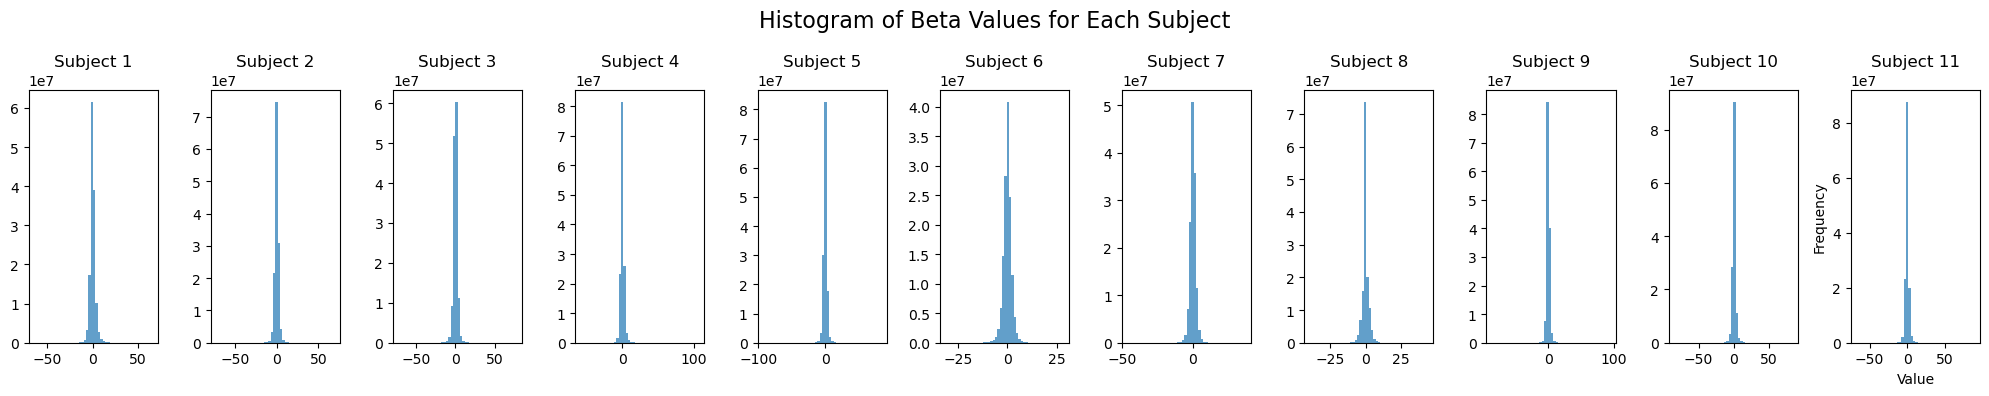

In [16]:
fig, axes = plt.subplots(1, beta_series_arr.shape[0], figsize=(20, 4))  # Create subplots for each subject

for subj_idx in range(beta_series_arr.shape[0]):
    # Extract data for the current subject
    subject_data = beta_series_arr[subj_idx, ...].flatten()

    # Plot histogram for the current subject
    axes[subj_idx].hist(subject_data, bins=50, alpha=0.7)
    axes[subj_idx].set_title(f'Subject {subj_idx + 1}')

# Set labels and title
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.suptitle('Histogram of Beta Values for Each Subject', fontsize=16)
plt.tight_layout()

# Show plot
plt.show()

plot z distribution

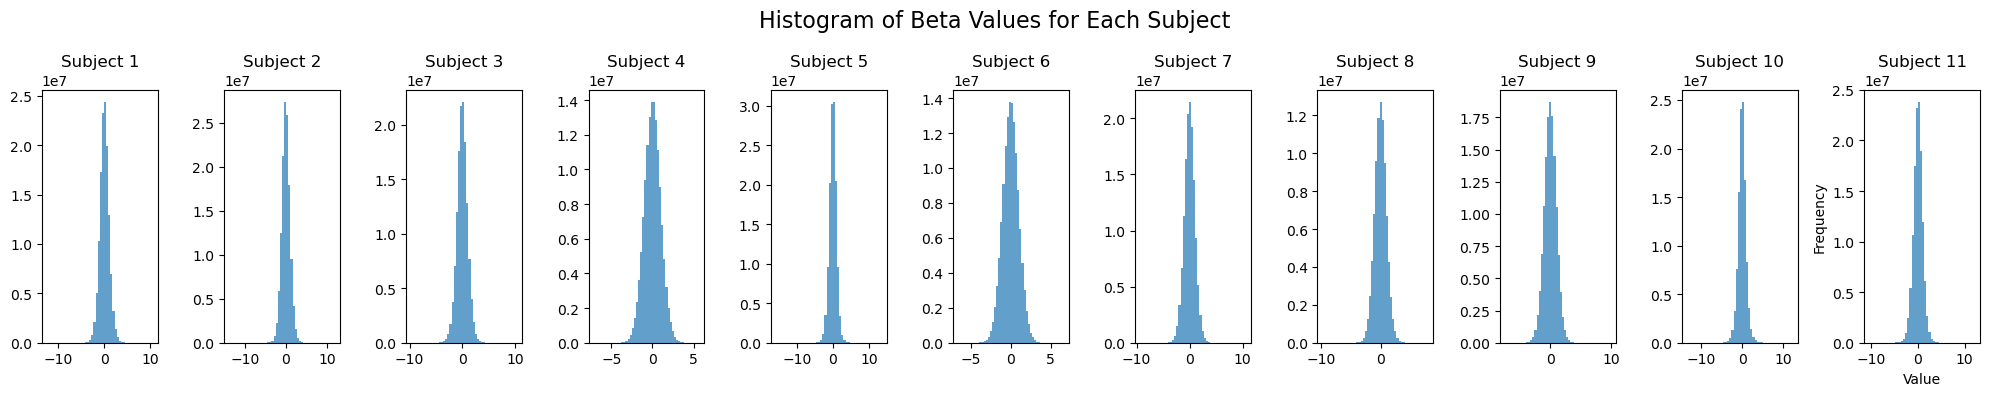

In [19]:
fig, axes = plt.subplots(1, beta_series_arr.shape[0], figsize=(20, 4))  # Create subplots for each subject

for subj_idx in range(z_series_arr.shape[0]):
    # Extract data for the current subject
    subject_data = z_series_arr[subj_idx, ...].flatten()

    # Plot histogram for the current subject
    axes[subj_idx].hist(subject_data, bins=50, alpha=0.7)
    axes[subj_idx].set_title(f'Subject {subj_idx + 1}')

# Set labels and title
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.suptitle('Histogram of Beta Values for Each Subject', fontsize=16)
plt.tight_layout()

# Show plot
plt.show()

#### Check masked z series

c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\plotting\html_stat_map.py:198: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(stat_map_img, ensure_finite=True)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



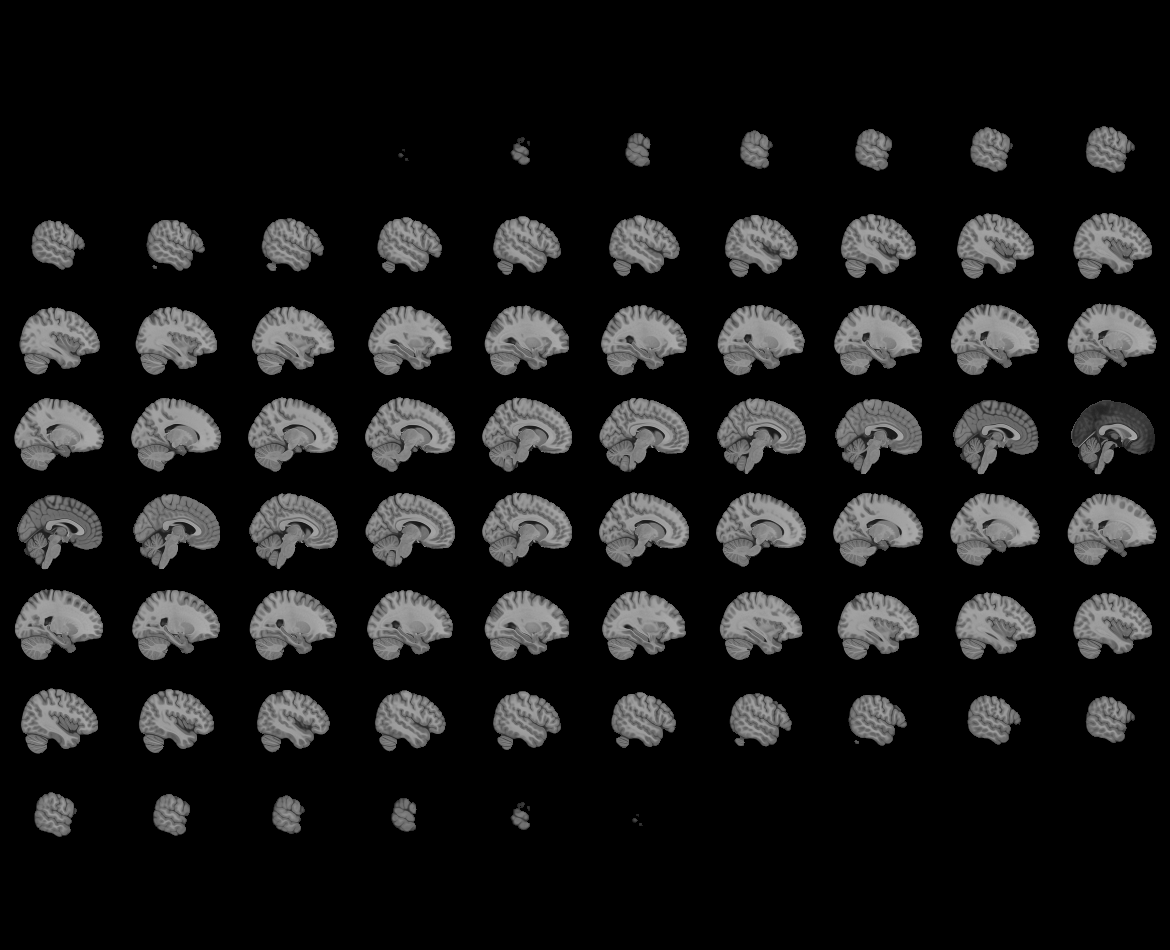
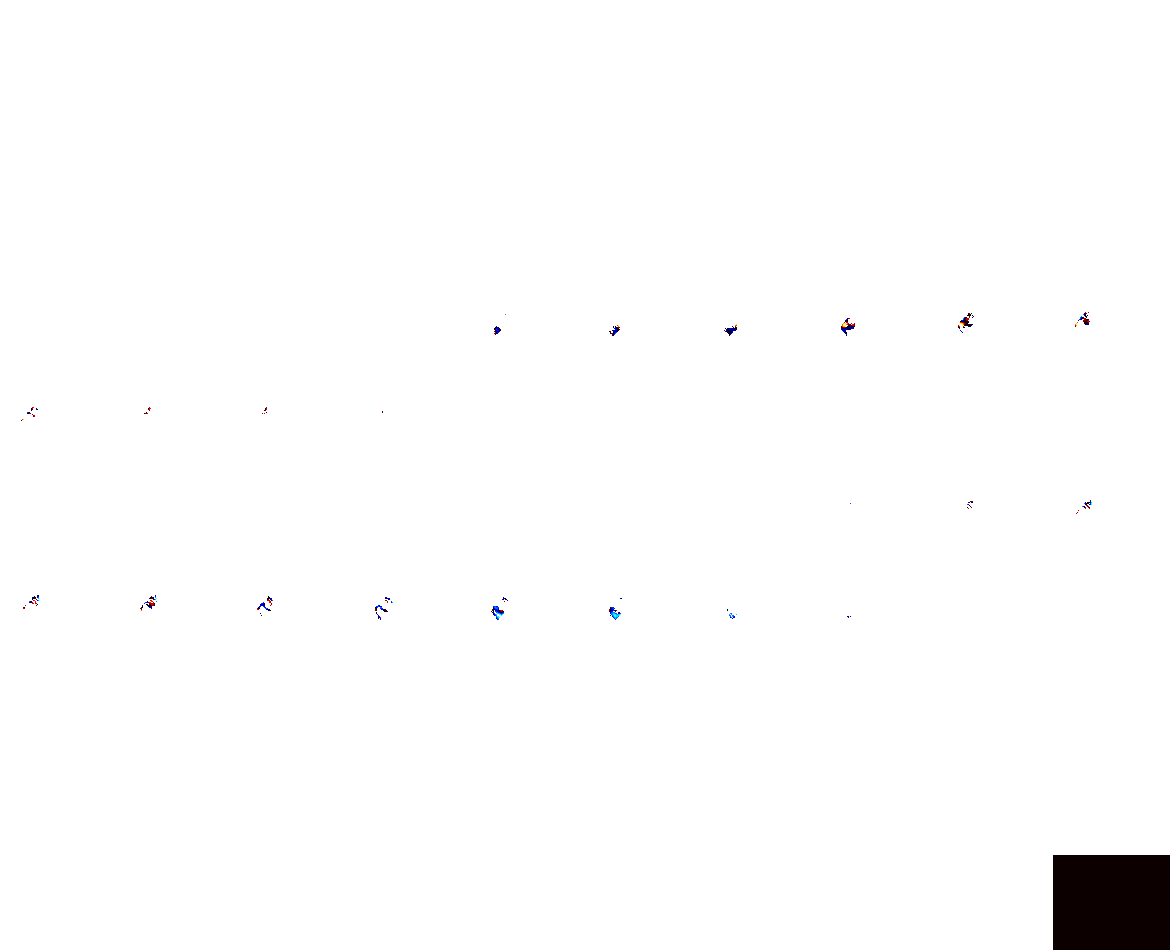

In [60]:
z_series_arr_test = z_series_arr[1,100,:]
z_series_arr_test_1d = z_series_arr_test.flatten()
# z_series_arr_test_1d = z_series_arr_test.flatten(order = 'F')

flat_roi_data = roi_masks['IPS'].get_fdata()
# roi_flat = flat_roi_data.flatten(order='F') # this is the same as reshape(1, -1)
# roi_flat = flat_roi_data.flatten()
roi_flat = flat_roi_data.flatten()
indices = np.where(roi_flat)[0]
roi_betas = np.squeeze(z_series_arr_test_1d)[indices]

test_mask_data = np.empty((79, 95, 79))
test_mask_data[:] = np.nan
test_mask_data_flat = test_mask_data.flatten()
test_mask_data_flat[indices] = roi_betas
# With no F order
from nilearn.image import new_img_like
test_mask_nii = new_img_like(resampled_mask, test_mask_data_flat.reshape(79, 95, 79))
view = plotting.view_img(test_mask_nii)
view


# Load stimuli sequence

In [23]:
stim_dir = 'F:\yujun\projects\LAB_IAPS_AI\data\stimulus_v2'
stim_files = natsorted(os.listdir(stim_dir))
stim_files

['r1.txt',
 'r2.txt',
 'r3.txt',
 'r4.txt',
 'r5.txt',
 'r6.txt',
 'r7.txt',
 'r8.txt',
 'r9.txt',
 'r10.txt']

In [24]:
stimuli = []
for i, file in enumerate(stim_files):
    txt_path = os.path.join(stim_dir, file)
    data_array = np.loadtxt(txt_path, dtype=str)
    stimuli.append(data_array)
stimuli = np.array(stimuli).flatten()

Add stimuli types

In [28]:
stim_types = pd.read_csv('F:\yujun\projects\LAB_IAPS_AI\data\iaps_emotion_category_v2.csv')
stim_types

,id,iaps_id,img,emotion_type,AI,group
0,1205,1205,1205.jpg,unpleasant,NO,unpleasant
1,1205_2,1205,1205_2.jpg,unpleasant,YES,unpleasantAI
2,1270,1270,1270.jpg,unpleasant,NO,unpleasant
3,1270_0,1270,1270_0.jpg,unpleasant,YES,unpleasantAI
4,1419,1419,1419.jpg,neutral,NO,neutral
...,...,...,...,...,...,...
115,9900_2,9900,9900_2.jpg,unpleasant,YES,unpleasantAI
116,9905,9905,9905.jpg,unpleasant,NO,unpleasant
117,9905_2,9905,9905_2.jpg,unpleasant,YES,unpleasantAI
118,9909,9909,9909.jpg,unpleasant,NO,unpleasant


In [29]:
stimuli_df = pd.DataFrame({'Sequence': stimuli})
# Add an 'OriginalOrder' column to the df DataFrame
stimuli_df['OriginalOrder'] = stimuli_df.index
stimuli_df

,Sequence,OriginalOrder
0,2045_2.jpg,0
1,6211_0.jpg,1
2,5395_2.jpg,2
3,3230_0.jpg,3
4,2550.jpg,4
...,...,...
595,3016_1.jpg,595
596,9140.jpg,596
597,2446.jpg,597
598,9570_1.jpg,598


In [30]:
# Merge the two DataFrames based on the StimulusID column
merged_df = stimuli_df.merge(stim_types, left_on='Sequence', right_on='img')
# Sort the merged DataFrame based on the 'OriginalOrder' column
merged_df = merged_df.sort_values(by='OriginalOrder')
stimuli = merged_df[['OriginalOrder','img','emotion_type', 'AI', 'group']].reset_index(drop=True)
stimuli

,OriginalOrder,img,emotion_type,AI,group
0,0,2045_2.jpg,pleasant,YES,pleasantAI
1,1,6211_0.jpg,unpleasant,YES,unpleasantAI
2,2,5395_2.jpg,neutral,YES,neutralAI
3,3,3230_0.jpg,unpleasant,YES,unpleasantAI
4,4,2550.jpg,pleasant,NO,pleasant
...,...,...,...,...,...
595,595,3016_1.jpg,unpleasant,YES,unpleasantAI
596,596,9140.jpg,unpleasant,NO,unpleasant
597,597,2446.jpg,neutral,NO,neutral
598,598,9570_1.jpg,unpleasant,YES,unpleasantAI


In [120]:
stimuli.to_csv("./stimuli_600trials.csv")

In [25]:
stimuli = pd.read_csv("./stimuli_600trials.csv")

In [26]:
stimuli

,Unnamed: 0,OriginalOrder,img,emotion_type,AI,group
0,0,0,2045_2.jpg,pleasant,YES,pleasantAI
1,1,1,6211_0.jpg,unpleasant,YES,unpleasantAI
2,2,2,5395_2.jpg,neutral,YES,neutralAI
3,3,3,3230_0.jpg,unpleasant,YES,unpleasantAI
4,4,4,2550.jpg,pleasant,NO,pleasant
...,...,...,...,...,...,...
595,595,595,3016_1.jpg,unpleasant,YES,unpleasantAI
596,596,596,9140.jpg,unpleasant,NO,unpleasant
597,597,597,2446.jpg,neutral,NO,neutral
598,598,598,9570_1.jpg,unpleasant,YES,unpleasantAI


# Within condition decoding

In [27]:
decode_ids = []
decode_names = []

decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
decode_names.append('PL vs. Nt (natrual) images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'NO'))[0])
# decode_names.append('Pl vs. Up (natrual) images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
decode_names.append('Up vs. Nt (natrual) images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])
decode_names.append('Pl vs. Nt (AI) images.')
# decode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'YES'))[0])
# decode_names.append('Pl vs. Up (AI) images.')
decode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])
decode_names.append('Up vs. Nt (AI) images.')

decode_dict = dict(zip(decode_names, decode_ids))

In [28]:
decode_dict['Pl vs. Nt (AI) images.']

array([  0,   2,   5,   8,   9,  10,  13,  14,  23,  25,  27,  29,  33,
        35,  36,  42,  46,  49,  50,  54,  63,  66,  70,  75,  79,  83,
        85,  86,  87,  88,  90,  96,  97,  98, 101, 106, 112, 115, 118,
       119, 121, 123, 124, 125, 130, 139, 140, 144, 145, 154, 155, 158,
       159, 160, 163, 165, 166, 175, 176, 179, 181, 184, 188, 191, 193,
       201, 203, 204, 213, 214, 217, 219, 222, 225, 229, 230, 234, 236,
       237, 238, 241, 242, 245, 247, 251, 257, 258, 263, 264, 269, 274,
       275, 278, 284, 286, 291, 292, 294, 298, 299, 300, 302, 303, 306,
       309, 313, 314, 317, 322, 326, 329, 330, 331, 334, 343, 345, 349,
       350, 355, 358, 364, 373, 374, 375, 377, 378, 380, 381, 385, 388,
       390, 392, 393, 395, 405, 406, 410, 413, 414, 417, 426, 429, 439,
       440, 442, 450, 453, 455, 456, 457, 460, 461, 465, 466, 468, 474,
       475, 476, 478, 479, 481, 483, 485, 492, 496, 498, 502, 508, 509,
       510, 511, 512, 515, 517, 524, 525, 526, 531, 535, 536, 54

In [29]:
decode_ids[0].shape

(200,)

In [30]:
beta_arr = beta_series_arr.reshape(beta_series_arr.shape[0], beta_series_arr.shape[1], -1)
beta_arr.shape

(11, 600, 592895)

In [31]:
z_arr = z_series_arr.reshape(z_series_arr.shape[0], z_series_arr.shape[1], -1)
z_arr.shape

(11, 600, 592895)

In [50]:
len(roi_masks)

16

In [52]:
roi_masks.keys()

dict_keys(['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'V3a', 'V3b', 'LO1', 'LO2', 'VO1', 'VO2', 'IPS', 'PHC1', 'PHC2'])

In [61]:
# dec_data = np.delete(z_arr, 3, axis=0)
# dec_data = beta_arr 
dec_data = z_arr
dec_data.shape

(11, 600, 592895)

In [72]:
subs =          ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub11', 'Sub12']
selected_subs = ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub9', 'Sub11', 'Sub12']
# Create a mapping from selected_subs to their corresponding index in subs list
selected_indices = [subs.index(sub) for sub in selected_subs]
selected_indices

[0, 1, 2, 3, 4, 5, 6, 8, 9, 10]

In [74]:
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.svm import SVC

# Assuming rskf, roi_masks, decode_dict, subs, beta_arr, stimuli, etc. are already defined

# Stratified 10-fold cross-validation
rskf  = RepeatedStratifiedKFold(n_splits=10, n_repeats=1, random_state=42)

rois = []

# Total number of iterations across rois, cases, and subjects
total_iterations = len(roi_masks) * len(decode_dict) * len(selected_indices) * rskf.get_n_splits()

with tqdm(total=total_iterations, desc="Decoding across ROIs, cases, and subjects") as pbar:
    for m, (roi_name, roi_mask) in enumerate(roi_masks.items()):
        # print(f"Decoding {roi_name}......")
        flat_roi_data = roi_mask.get_fdata()
        roi_flat = flat_roi_data.flatten()
        indices = np.where(roi_flat)[0]
        roi_betas = dec_data[:, :, indices]  # Assuming beta_arr has the shape (subjects, trials, voxels)

        cases = []
        for i, (decode_name, decode_id) in enumerate(decode_dict.items()):
            subjects = []
            for s in selected_indices:
                betas = roi_betas[s, decode_id, :]

                # # Standardization across trials
                # mean_trial = np.mean(betas, axis=0)
                # std_trial = np.std(betas, axis=0)
                # std_trial[std_trial == 0] = 1
                # betas_standarized_trial = (betas - mean_trial) / std_trial
                # nan_columns = np.any(np.isnan(betas_standarized_trial), axis=0)
                # betas_standarized_trial = betas_standarized_trial[:, ~nan_columns]

                # # Standardization across voxels
                # mean_voxel = np.mean(betas_standarized_trial, axis=1)[:, np.newaxis]
                # std_voxel = np.std(betas_standarized_trial, axis=1)[:, np.newaxis]
                # std_voxel[std_voxel == 0] = 1
                # betas_standarized = (betas_standarized_trial - mean_voxel) / std_voxel

                nan_columns = np.any(np.isnan(betas), axis=0)
                data = betas[:, ~nan_columns]

                # Assume `data` and `indices` are already defined
                assert data.shape[1] >= 0.8 * len(indices), \
                    f"Data second dimension {data.shape[1]} is less than 80% of the length of indices {len(indices)}, subject {s+1}, decoding case {decode_name}."


                labels = stimuli['emotion_type'][decode_id].reset_index(drop=True)

                sub_svc_scores = []
                for train_index, test_index in rskf.split(data, labels):
                    X_train, X_test = data[train_index], data[test_index]
                    y_train, y_test = labels[train_index], labels[test_index]

                    # Create SVC classifiers with different kernels
                    linear_svc = SVC(kernel='linear', random_state=42)

                    # Fit the model
                    linear_svc.fit(X_train, y_train)

                    # Evaluate the model
                    linear_score = linear_svc.score(X_test, y_test)
                    sub_svc_scores.append(linear_score)

                avgsub_svc_scores = np.mean(sub_svc_scores)
                subjects.append(avgsub_svc_scores)

                # Update tqdm after processing each subject
                pbar.update(1)

            cases.append(subjects)

        rois.append(cases)


Decoding across ROIs, cases, and subjects:  10%|█         | 640/6400 [10:59<1:38:53,  1.03s/it]


In [75]:
within_rois_decode = np.array(rois)
print(f"ROI: {within_rois_decode.shape[0]}, condition: {within_rois_decode.shape[1]}, subject: {within_rois_decode.shape[2]}")

ROI: 16, condition: 4, subject: 10


In [76]:
within_rois_decode = within_rois_decode.transpose(1,0,2)
within_rois_decode.shape

(4, 16, 10)

In [77]:
# np.save( "./outputs/7subs_within_kastner.npy", within_rois_decode)
np.save( "./outputs/11subs_within_kastner_z.npy", within_rois_decode)

In [131]:
rois_arr_trans = np.load("./outputs/11subs_within_kastner_z.npy")
rois_arr_trans.shape

(4, 65, 7)

## Kastner ROI Plottng

In [78]:
within_rois_decode.shape

(4, 16, 10)

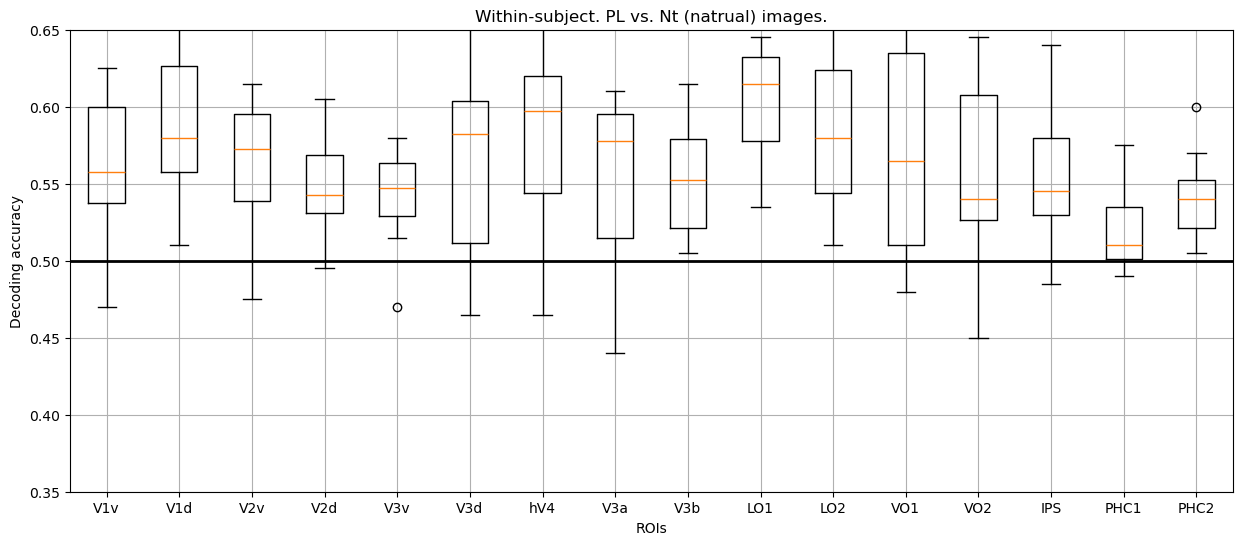

In [79]:
case_id = 0
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(within_rois_decode[case_id,:, :].T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {decode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 0.65)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

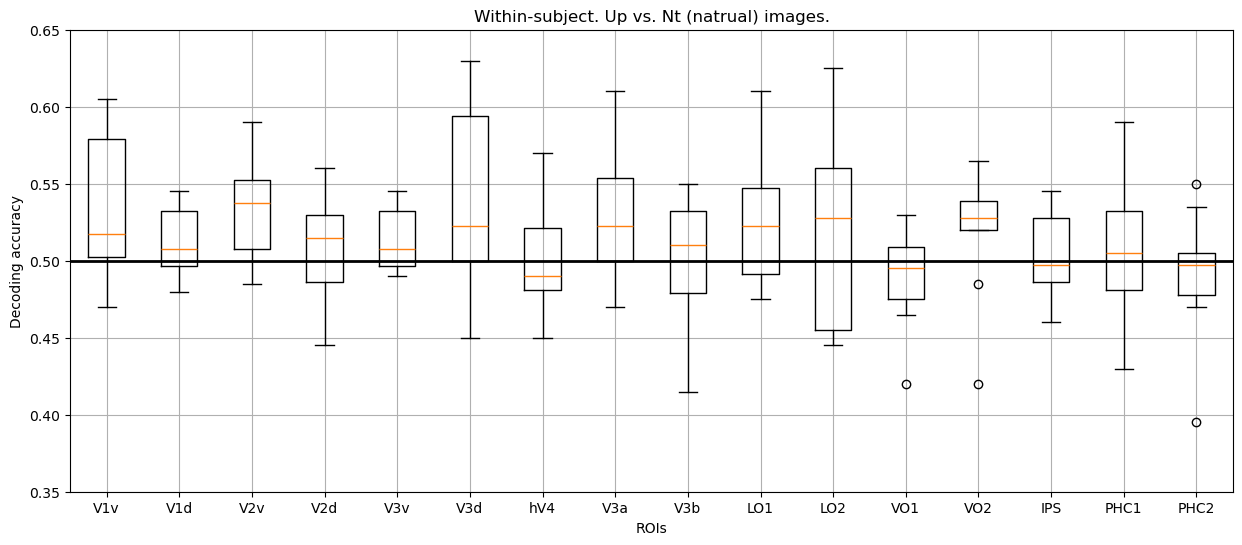

In [80]:
case_id = 1
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(within_rois_decode[case_id,:, :].T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {decode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 0.65)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

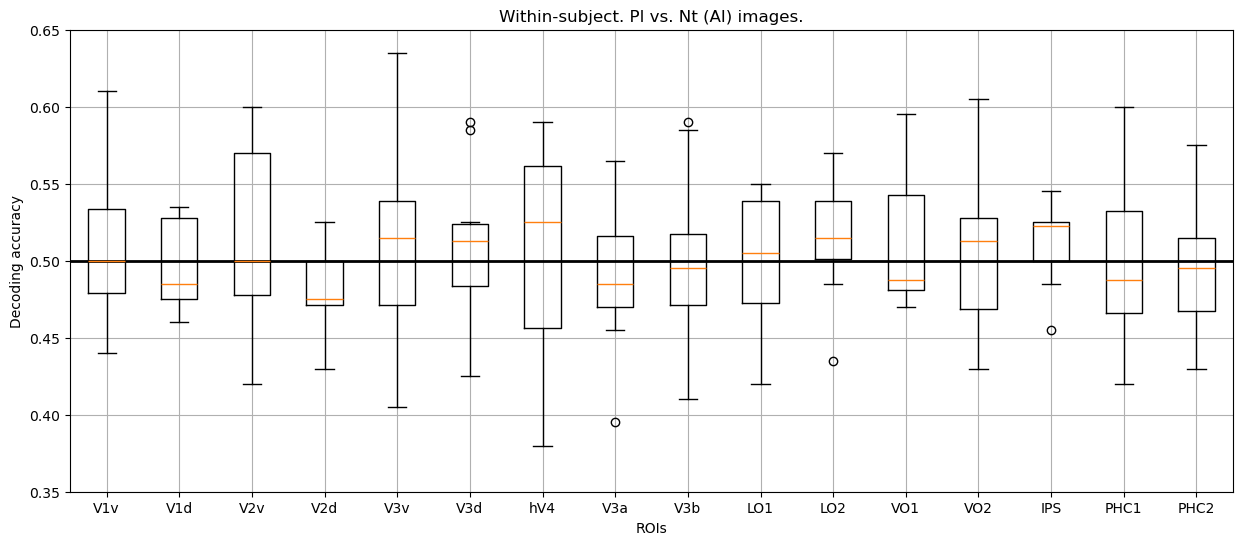

In [81]:
case_id = 2
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(within_rois_decode[case_id,:, :].T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {decode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 0.65)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

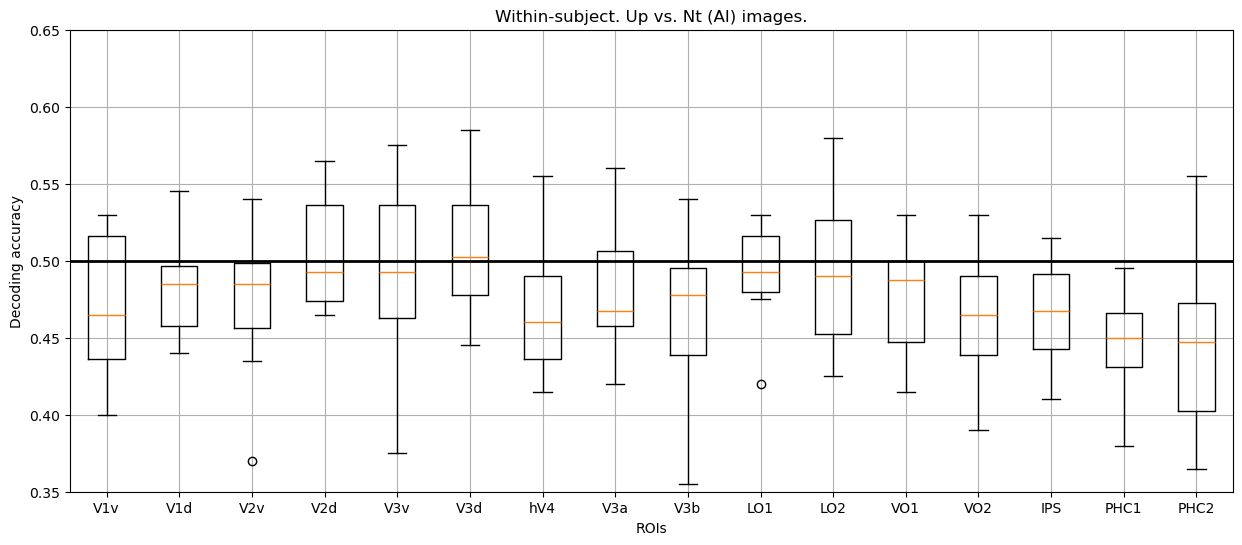

In [86]:
case_id = 3
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(within_rois_decode[case_id,:, :].T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {decode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 0.65)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

## AAL3 ROI plotting

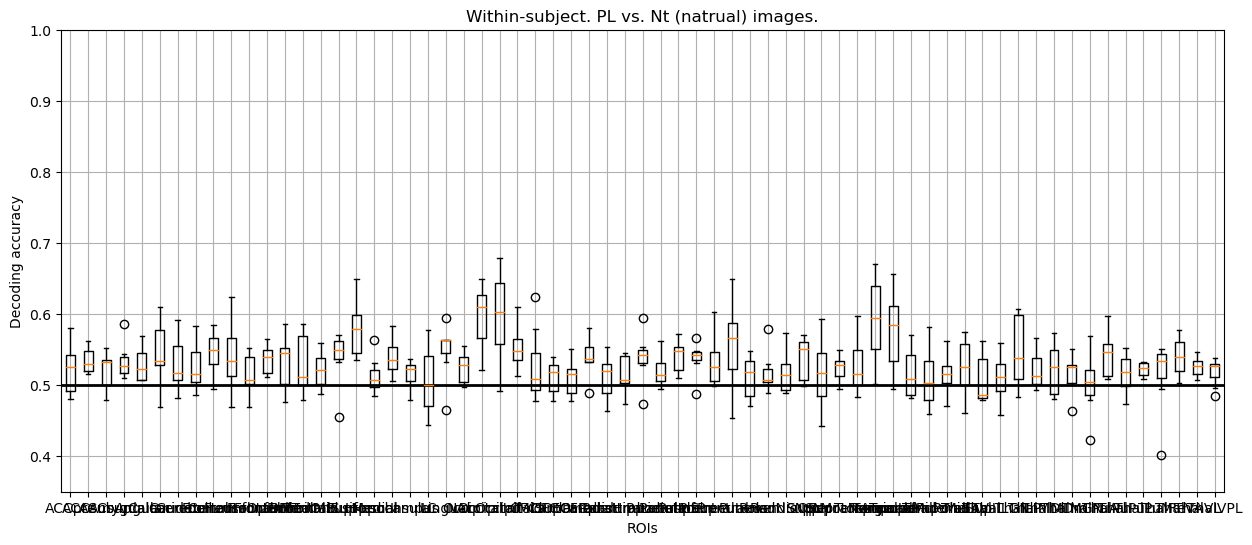

In [132]:
case_id = 0
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(within_rois_decode[case_id,:, :].T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {decode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 1.0)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

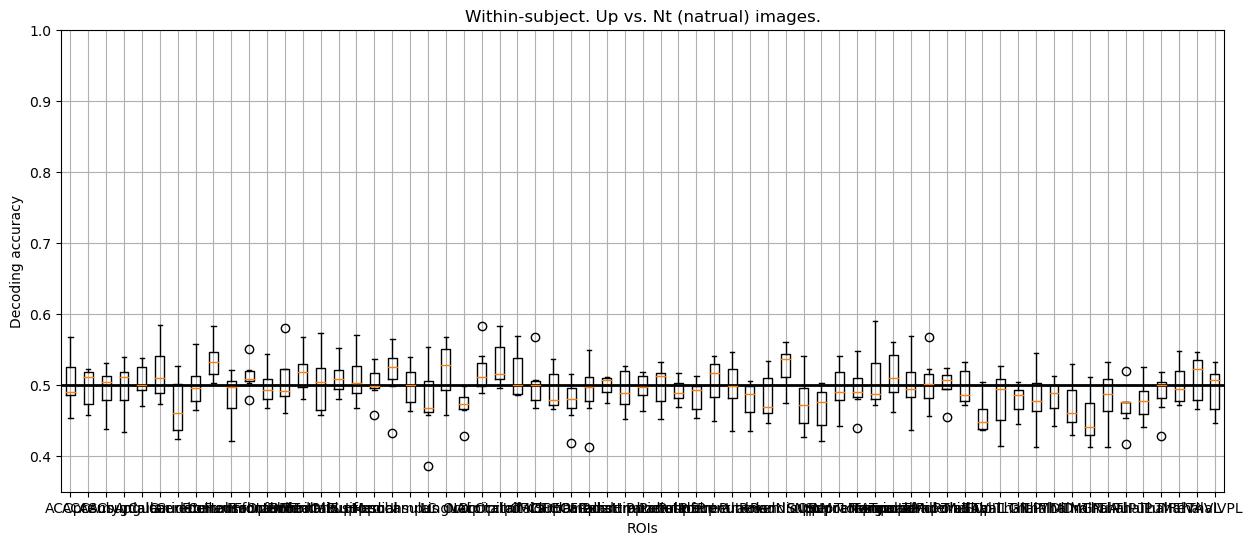

In [133]:
case_id = 1
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(within_rois_decode[case_id,:, :].T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {decode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 1.0)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

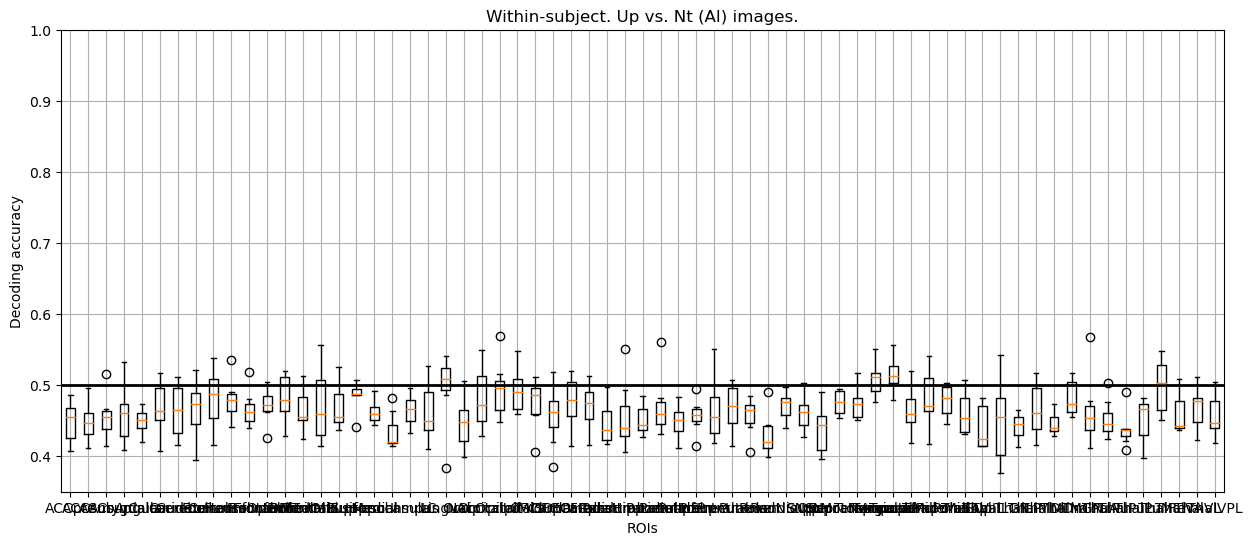

In [135]:
case_id = 3
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(within_rois_decode[case_id,:, :].T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Within-subject. {decode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 1.0)  # Set the y-axis limits
# Add a thick black line at y=0.5
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

# Within-subject, cross-condition Decoding

In [68]:
xdecode_ids = []
xdecode_names = []

xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
# xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'NO'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'NO'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])
# xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'pleasant') | (stimuli['emotion_type'] == 'unpleasant')) & (stimuli['AI'] == 'YES'))[0])
xdecode_ids.append(np.where(((stimuli['emotion_type'] == 'unpleasant') | (stimuli['emotion_type'] == 'neutral')) & (stimuli['AI'] == 'YES'))[0])

xdecode_names.append('Pleasant vs. Neutral, trained on natural and tested on AI')
# xdecode_names.append('Pleasant vs. Unpleasant, trained on natural and tested on AI')
xdecode_names.append('Unpleasant vs. Neutral, trained on natural and tested on AI')
xdecode_names.append('Pleasant vs. Neutral, trained on AI and tested on natrual')
# xdecode_names.append('Pleasant vs. Unpleasant, trained on AI and tested on natrual')
xdecode_names.append('Unpleasant vs. Neutral, trained on AI and tested on natrual')

In [98]:
z_arr.shape

(7, 600, 592895)

In [100]:
rois_xdecode = []
# Iterate through the values of roi_dict
for roi_name, roi_mask in  roi_masks.items():
    flat_roi_data = roi_mask.get_fdata()
    roi_flat = flat_roi_data.flatten()
    indices = np.where(roi_flat)[0]
    roi_betas = z_arr[:, :, indices]

    # print(f'Now decoding {roi_name}')

    cases = []
    for i, xdecode_id in enumerate(tqdm(xdecode_ids)):

        subjects = []
        for s in range(len(subs)):
            betas = roi_betas[s, xdecode_id, :]

            nan_columns = np.any(np.isnan(betas), axis=0)
            data_train = betas[:, ~nan_columns]
            label_train = stimuli['emotion_type'][xdecode_id].reset_index(drop=True)
 
            if i == 0:
                betas_test = roi_betas[s, xdecode_ids[2], :]
  
                nan_columns = np.any(np.isnan(betas_test), axis=0)
                data_test = betas_test[:, ~nan_columns]
                label_test = stimuli['emotion_type'][xdecode_ids[2]].reset_index(drop=True)
            elif i == 1:
                betas_test = roi_betas[s, xdecode_ids[3], :]
 
                nan_columns = np.any(np.isnan(betas_test), axis=0)
                data_test = betas_test[:, ~nan_columns]
                label_test = stimuli['emotion_type'][xdecode_ids[3]].reset_index(drop=True)
            elif i == 2:
                betas_test = roi_betas[s, xdecode_ids[0], :]

                nan_columns = np.any(np.isnan(betas_test), axis=0)
                data_test = betas_test[:, ~nan_columns]
                label_test = stimuli['emotion_type'][xdecode_ids[0]].reset_index(drop=True)
            elif i == 3:
                betas_test = roi_betas[s, xdecode_ids[1], :]
 
                nan_columns = np.any(np.isnan(betas_test), axis=0)
                data_test = betas_test[:, ~nan_columns]
                label_test = stimuli['emotion_type'][xdecode_ids[1]].reset_index(drop=True)

            # Create SVC classifiers with different kernels
            linear_svc = SVC(kernel='linear')

            # Fit the model
            linear_svc.fit(data_train, label_train)

            # Evaluate the model
            linear_score = linear_svc.score(data_test, label_test)

            # print(f"{decode_names[i]} Trial count: {len(decode_ids[i])}")
            # print("Average Linear SVC accuracy:", avg_linear_score)
            # print("------------------")
            subjects.append(linear_score)

        cases.append(subjects)

    # print('=============================================')
    rois_xdecode.append(cases)

100%|██████████| 4/4 [00:03<00:00,  1.01it/s]


In [101]:
xcond_rois_arr = np.array(np.array(rois_xdecode))
xcond_rois_arr.shape

(16, 4, 7)

In [102]:
xcond_rois_arr_trans = xcond_rois_arr.transpose(1,0,2)
xcond_rois_arr_trans.shape

(4, 16, 7)

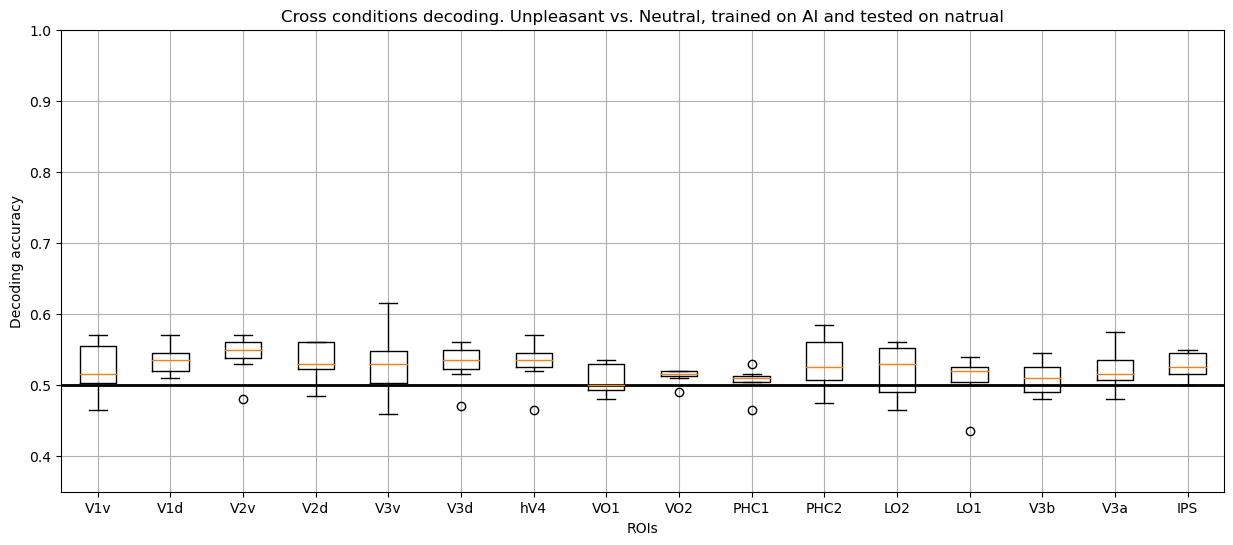

In [112]:
case_id = 3
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(xcond_rois_arr_trans[case_id].T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Cross conditions decoding. {xdecode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)
plt.ylim(0.35, 1.0)  # Set the y-axis limits
plt.axhline(y=0.5, color='black', linewidth=2)

# Display the box plots
plt.show()

# Code to match previous result

In [85]:
beta_arr.shape

(7, 600, 592895)

In [86]:
beta_arr2 = beta_arr[:3]

In [88]:
beta_arr2.shape

(3, 600, 592895)

In [89]:
rois_xdecode = []
# Iterate through the values of roi_dict
for roi_name, roi_mask in  roi_masks.items():
    flat_roi_data = roi_mask.get_fdata()
    roi_flat = flat_roi_data.flatten()
    indices = np.where(roi_flat)[0]
    roi_betas = beta_arr2[:, :, indices]

    # print(f'Now decoding {roi_name}')

    cases = []
    for i, xdecode_id in enumerate(tqdm(xdecode_ids)):

        subjects = []
        for s in range(len(subs[:3])):
            betas = roi_betas[s, xdecode_ids, :]
            
            # Standardization across trials
            mean_trial = np.mean(betas, axis=0)
            std_trial = np.std(betas, axis=0)
            std_trial[std_trial == 0] = 1 
            betas_standarized_trial = (betas - mean_trial) / std_trial
            nan_columns = np.any(np.isnan(betas_standarized_trial), axis=0)
            betas_standarized_trial = betas_standarized_trial[:, ~nan_columns]
            # Standardization across trials
            mean_voxel = np.mean(betas_standarized_trial, axis=1)[:, np.newaxis]
            std_voxel = np.std(betas_standarized_trial, axis=1)[:, np.newaxis] 
            std_voxel[std_voxel == 0] = 1 
            betas_standarized = (betas_standarized_trial - mean_voxel) / std_voxel

            nan_columns = np.any(np.isnan(betas_standarized_trial), axis=0)
            data_train = betas_standarized_trial[:, ~nan_columns]
            label_train = stimuli['emotion_type'][xdecode_id].reset_index(drop=True)
         
            if i == 0:
                betas_test = roi_betas[s, xdecode_ids[2], :]
                # Standardization across trials
                mean_trial = np.mean(betas_test, axis=0)
                std_trial = np.std(betas_test, axis=0)
                std_trial[std_trial == 0] = 1 
                betas_standarized_trial = (betas_test - mean_trial) / std_trial
                nan_columns = np.any(np.isnan(betas_standarized_trial), axis=0)
                betas_standarized_trial = betas_standarized_trial[:, ~nan_columns]
                # Standardization across trials
                mean_voxel = np.mean(betas_standarized_trial, axis=1)[:, np.newaxis]
                std_voxel = np.std(betas_standarized_trial, axis=1)[:, np.newaxis] 
                std_voxel[std_voxel == 0] = 1 
                betas_standarized = (betas_standarized_trial - mean_voxel) / std_voxel

                nan_columns = np.any(np.isnan(betas_standarized_trial), axis=0)
                data_test = betas_standarized_trial[:, ~nan_columns]
                label_test = stimuli['emotion_type'][xdecode_ids[2]].reset_index(drop=True)
            elif i == 1:
                betas_test = roi_betas[s, xdecode_ids[3], :]
                # Standardization across trials
                mean_trial = np.mean(betas_test, axis=0)
                std_trial = np.std(betas_test, axis=0)
                std_trial[std_trial == 0] = 1 
                betas_standarized_trial = (betas_test - mean_trial) / std_trial
                nan_columns = np.any(np.isnan(betas_standarized_trial), axis=0)
                betas_standarized_trial = betas_standarized_trial[:, ~nan_columns]
                # Standardization across trials
                mean_voxel = np.mean(betas_standarized_trial, axis=1)[:, np.newaxis]
                std_voxel = np.std(betas_standarized_trial, axis=1)[:, np.newaxis] 
                std_voxel[std_voxel == 0] = 1 
                betas_standarized = (betas_standarized_trial - mean_voxel) / std_voxel

                nan_columns = np.any(np.isnan(betas_standarized_trial), axis=0)
                data_test = betas_standarized_trial[:, ~nan_columns]
                label_test = stimuli['emotion_type'][xdecode_ids[3]].reset_index(drop=True)
            elif i == 2:
                betas_test = roi_betas[s, xdecode_ids[0], :]
                # Standardization across trials
                mean_trial = np.mean(betas_test, axis=0)
                std_trial = np.std(betas_test, axis=0)
                std_trial[std_trial == 0] = 1 
                betas_standarized_trial = (betas_test - mean_trial) / std_trial
                nan_columns = np.any(np.isnan(betas_standarized_trial), axis=0)
                betas_standarized_trial = betas_standarized_trial[:, ~nan_columns]
                # Standardization across trials
                mean_voxel = np.mean(betas_standarized_trial, axis=1)[:, np.newaxis]
                std_voxel = np.std(betas_standarized_trial, axis=1)[:, np.newaxis] 
                std_voxel[std_voxel == 0] = 1 
                betas_standarized = (betas_standarized_trial - mean_voxel) / std_voxel

                nan_columns = np.any(np.isnan(betas_standarized_trial), axis=0)
                data_test = betas_standarized_trial[:, ~nan_columns]
                label_test = stimuli['emotion_type'][xdecode_ids[0]].reset_index(drop=True)
            elif i == 3:
                betas_test = roi_betas[s, xdecode_ids[1], :]
                # Standardization across trials
                mean_trial = np.mean(betas_test, axis=0)
                std_trial = np.std(betas_test, axis=0)
                std_trial[std_trial == 0] = 1 
                betas_standarized_trial = (betas_test - mean_trial) / std_trial
                nan_columns = np.any(np.isnan(betas_standarized_trial), axis=0)
                betas_standarized_trial = betas_standarized_trial[:, ~nan_columns]
                # Standardization across trials
                mean_voxel = np.mean(betas_standarized_trial, axis=1)[:, np.newaxis]
                std_voxel = np.std(betas_standarized_trial, axis=1)[:, np.newaxis] 
                std_voxel[std_voxel == 0] = 1 
                betas_standarized = (betas_standarized_trial - mean_voxel) / std_voxel

                nan_columns = np.any(np.isnan(betas_standarized_trial), axis=0)
                data_test = betas_standarized_trial[:, ~nan_columns]
                label_test = stimuli['emotion_type'][xdecode_ids[1]].reset_index(drop=True)

            # Create SVC classifiers with different kernels
            linear_svc = SVC(kernel='linear')

            # Fit the model
            linear_svc.fit(data_train, label_train)

            # Evaluate the model
            linear_score = linear_svc.score(data_test, label_test)

            # print(f"{decode_names[i]} Trial count: {len(decode_ids[i])}")
            # print("Average Linear SVC accuracy:", avg_linear_score)
            # print("------------------")
            subjects.append(linear_score)

        cases.append(subjects)

    # print('=============================================')
    rois_xdecode.append(cases)

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:02<00:00,  1.91it/s]


In [90]:
xcond_rois_arr = np.array(np.array(rois_xdecode))
xcond_rois_arr.shape

(16, 4, 3)

In [91]:
xcond_rois_arr_trans = xcond_rois_arr.transpose(1,0,2)
xcond_rois_arr_trans.shape

(4, 16, 3)

z across trial, not across 

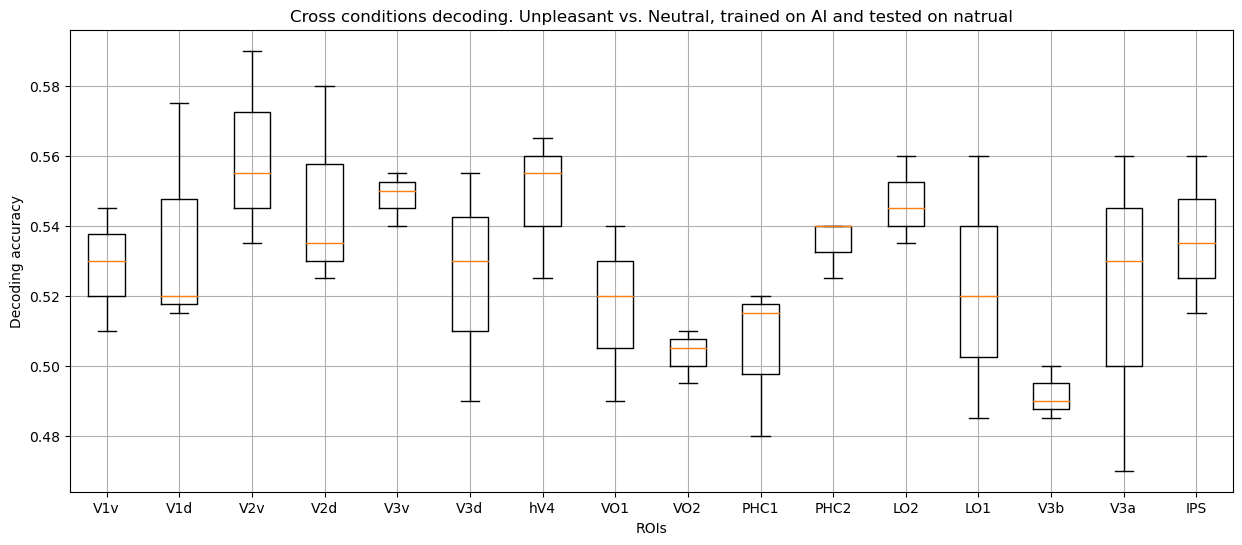

In [97]:
case_id = 3
# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(xcond_rois_arr_trans[case_id].T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Cross conditions decoding. {xdecode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)

# Display the box plots
plt.show()

# Previous result

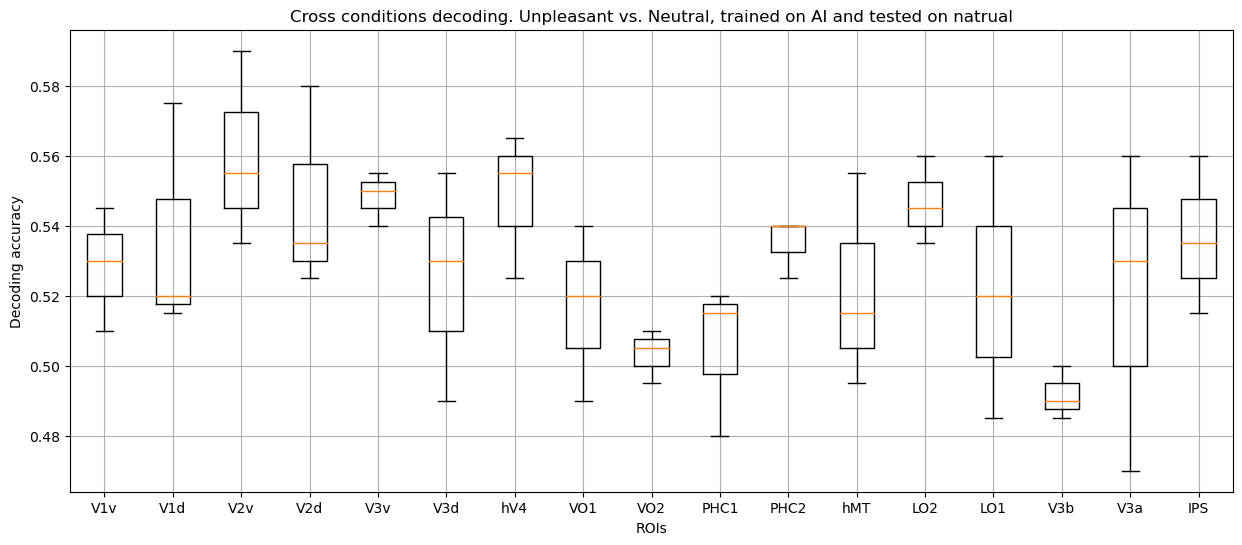

In [272]:
case_id = 5

# Create a box plot for each row of the data
plt.figure(figsize=(15, 6))  # Create a figure
plt.boxplot(xcond_rois_arr_trans[case_id].T)  # Transpose data and create box plots
plt.xlabel('ROIs')  # Add X-axis label
plt.xticks(np.arange(1,len(roi_masks)+1), roi_masks.keys())
plt.ylabel('Decoding accuracy')  # Add Y-axis label
plt.title(f'Cross conditions decoding. {xdecode_names[case_id]}')  # Add a title
plt.grid(True)  # Add a grid (optional)

# Display the box plots
plt.show()

In [250]:
np.save( "./outputs/3subs_xcond_43rois_z.npy", xcond_rois_arr_trans)